In [1]:
# Cell 1: Setup, imports, and environment check
# Project: Fine-tune YOLOv8n for hazard/obstacle detection (potholes, debris),
# extending Tripathagamini-S with new object classes beyond existing tracking.
# Architecture: YOLOv8n - convolutional backbone (CSPDarknet) + PANet neck +
# detection head. No transformer, no attention mechanism, no LLM component.

import os
import json
import time
import platform
import warnings

warnings.filterwarnings("ignore")

import torch

BASE_DIR = "/kaggle/working"
DATA_DIR = os.path.join(BASE_DIR, "data")
MODEL_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
RUNS_DIR = os.path.join(BASE_DIR, "runs")

for d in [DATA_DIR, MODEL_DIR, RESULTS_DIR, RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

RESULTS_FILE = os.path.join(RESULTS_DIR, "results.json")

if not os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "w") as f:
        json.dump({}, f, indent=2)


def load_results():
    with open(RESULTS_FILE, "r") as f:
        return json.load(f)


def save_results(new_data: dict):
    """Merge new_data into results.json and persist to disk immediately,
    so progress is not lost if the Kaggle session terminates unexpectedly."""
    results = load_results()
    results.update(new_data)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)


device_info = {
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "num_gpus": torch.cuda.device_count(),
    "gpu_names": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())] if torch.cuda.is_available() else [],
    "python_version": platform.python_version(),
}

print("Environment check:")
for k, v in device_info.items():
    print(f"  {k}: {v}")

save_results({"environment": device_info})

Environment check:
  torch_version: 2.10.0+cu128
  cuda_available: True
  num_gpus: 2
  gpu_names: ['Tesla T4', 'Tesla T4']
  python_version: 3.12.13


In [2]:
# Cell 2: Install Ultralytics YOLOv8 and load the pretrained YOLOv8n checkpoint
# YOLOv8n is a small, fully convolutional detector (CSPDarknet backbone,
# PANet neck, decoupled detection head). This checkpoint is pretrained on
# COCO and will be fine-tuned on hazard/obstacle classes in a later cell.

!pip install -q ultralytics

from ultralytics import YOLO

# Load the nano-sized pretrained checkpoint. This is downloaded from
# Ultralytics' own release assets (not Hugging Face Hub), avoiding the
# earlier HF download stall entirely.
model = YOLO("yolov8n.pt")

print("Model architecture summary:")
model.info()

# Record baseline model size on disk for later comparison against any
# quantized/exported version.
checkpoint_path = "yolov8n.pt"
if os.path.exists(checkpoint_path):
    size_mb = os.path.getsize(checkpoint_path) / (1024 ** 2)
    print(f"Checkpoint size on disk: {size_mb:.2f} MB")
else:
    size_mb = None

save_results({
    "base_model": "yolov8n.pt",
    "base_checkpoint_size_mb": round(size_mb, 2) if size_mb else None,
})

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model architecture summary:
YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Checkpoint size on disk: 6.25 MB


In [3]:
# Cell 3: Locate the attached pothole/obstacle dataset and prepare YOLO config
# The dataset is expected to be attached via Kaggle's Input panel (read-only,
# does not consume output storage quota). We only write a small data.yaml
# config file to /kaggle/working, not copies of the images themselves.

import glob

# List attached input datasets to confirm what got mounted.
input_datasets = glob.glob("/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized")
print("Attached input datasets:")
for d in input_datasets:
    print(" ", d)



DATASET_ROOT = input_datasets[0] if input_datasets else None
print(f"\nUsing dataset root: {DATASET_ROOT}")

if DATASET_ROOT:
    for root, dirs, files in os.walk(DATASET_ROOT):
        level = root.replace(DATASET_ROOT, "").count(os.sep)
        indent = "  " * level
        print(f"{indent}{os.path.basename(root)}/")
        if level < 2:
            for f in files[:5]:
                print(f"{indent}  {f}")

# Check if the dataset already ships its own data.yaml (common for
# Roboflow-exported Kaggle datasets). If so, we reuse it directly instead
# of duplicating image paths into our own working-directory copy.
existing_yaml = glob.glob(os.path.join(DATASET_ROOT, "*.yaml")) if DATASET_ROOT else []
print(f"\nExisting data.yaml found: {existing_yaml}")

save_results({
    "dataset_root": DATASET_ROOT,
    "existing_yaml_found": existing_yaml,
})

Attached input datasets:
  /kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized

Using dataset root: /kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized
pothole-detection-dataset-yolov11-optimized/
  README.dataset.txt
  README.roboflow.txt
  data.yaml
  valid/
    labels/
    images/
  test/
    labels/
    images/
  train/
    labels/
    images/

Existing data.yaml found: ['/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/data.yaml']


In [4]:
# Cell 4: Correct dataset path references and consolidate class metadata

import yaml

original_yaml_path = "/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/data.yaml"

with open(original_yaml_path, "r") as f:
    original_config = yaml.safe_load(f)

print("Original data.yaml contents:")
print(original_config)

# Roboflow exports store paths relative to the export root, which does not
# match the mount point Kaggle assigns to read-only inputs. Only nc/names
# are trustworthy as-is; train/val/test paths must be rebuilt.
class_names = original_config.get("names", [])
num_classes = original_config.get("nc", len(class_names))

print(f"\nNumber of classes: {num_classes}")
print(f"Class names: {class_names}")

corrected_config = {
    "train": os.path.join(DATASET_ROOT, "train", "images"),
    "val": os.path.join(DATASET_ROOT, "valid", "images"),
    "test": os.path.join(DATASET_ROOT, "test", "images"),
    "nc": num_classes,
    "names": class_names,
}

# Written to /kaggle/working since the input mount is read-only; this file
# is a few KB and has no bearing on the output storage limit.
corrected_yaml_path = os.path.join(BASE_DIR, "data.yaml")
with open(corrected_yaml_path, "w") as f:
    yaml.dump(corrected_config, f, default_flow_style=False)

print(f"\nCorrected data.yaml written to: {corrected_yaml_path}")
print(corrected_config)

# Per-split image counts confirm the mounted paths actually resolve to real
# files before any GPU time is spent on training.
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(DATASET_ROOT, split, "images")
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"{split}: {count} images")

save_results({
    "data_yaml_path": corrected_yaml_path,
    "num_classes": num_classes,
    "class_names": class_names,
})

Original data.yaml contents:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['pothole'], 'roboflow': {'workspace': 'vasanthakumar662005', 'project': 'pothole-pq3lu', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/vasanthakumar662005/pothole-pq3lu/dataset/1'}}

Number of classes: 1
Class names: ['pothole']

Corrected data.yaml written to: /kaggle/working/data.yaml
{'train': '/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/train/images', 'val': '/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/valid/images', 'test': '/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/test/images', 'nc': 1, 'names': ['pothole']}
train: 3345 images
valid: 397 images
test: 198 images


In [5]:
# Cell 5: Fine-tune YOLOv8n on the pothole dataset, with resume-on-restart
# logic so a session timeout does not lose progress already made.

from ultralytics import YOLO

RUN_NAME = "yolov8n_pothole"
last_checkpoint = os.path.join(RUNS_DIR, "detect", RUN_NAME, "weights", "last.pt")

# If a checkpoint from a prior (interrupted) session already exists, resume
# training from it instead of reinitializing from the base COCO weights.
# Ultralytics' resume mechanism restores optimizer state and epoch count,
# not just model weights, so this preserves the actual training trajectory.
if os.path.exists(last_checkpoint):
    print(f"Resuming from existing checkpoint: {last_checkpoint}")
    model = YOLO(last_checkpoint)
    resume_flag = True
else:
    print("No prior checkpoint found, starting from pretrained yolov8n.pt")
    model = YOLO("yolov8n.pt")
    resume_flag = False

start_time = time.time()

# epochs=100 raises the ceiling since transfer learning on this small,
# single-class dataset is unlikely to need it, but patience=15 (early
# stopping) will cut training short automatically once validation mAP
# plateaus, so the higher ceiling costs nothing if convergence is fast.
# device=[0, 1] engages both T4s via DDP. save_period writes a checkpoint
# every 5 epochs in addition to the always-updated last.pt/best.pt,
# bounding disk writes against the output quota rather than checkpointing
# every single epoch.
results = model.train(
    data=corrected_yaml_path,
    epochs=400,
    imgsz=640,
    batch=32,
    device=[0, 1],
    project=RUNS_DIR,
    name=RUN_NAME,
    exist_ok=True,
    resume=resume_flag,
    save_period=5,
    patience=30,
    workers=4,
    verbose=True,
)

elapsed_minutes = (time.time() - start_time) / 60
print(f"\nTraining segment completed in {elapsed_minutes:.2f} minutes")

save_results({
    "training_epochs_requested": 100,
    "training_elapsed_minutes_this_session": round(elapsed_minutes, 2),
    "resumed_from_checkpoint": resume_flag,
    "run_dir": os.path.join(RUNS_DIR, "detect", RUN_NAME),
})

No prior checkpoint found, starting from pretrained yolov8n.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=400, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yo

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:99: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.7it/s 2.6s0.3ss
                   all        397        973      0.666       0.31       0.39      0.199

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/400      2.51G      1.541      1.856      1.489         35        640: 100% ━━━━━━━━━━━━ 105/105 2.8it/s 37.2s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0it/s 1.8s0.3s
                   all        397        973      0.389      0.232        0.2     0.0884

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/400      2.51G      1.595      1.719      1.519         28        640: 100% ━━━━━━━━━━━━ 105/105 3.1it/s 33.7s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 4.0it/s 1.7s0.3s
                   all        

Logged epochs: 277
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']


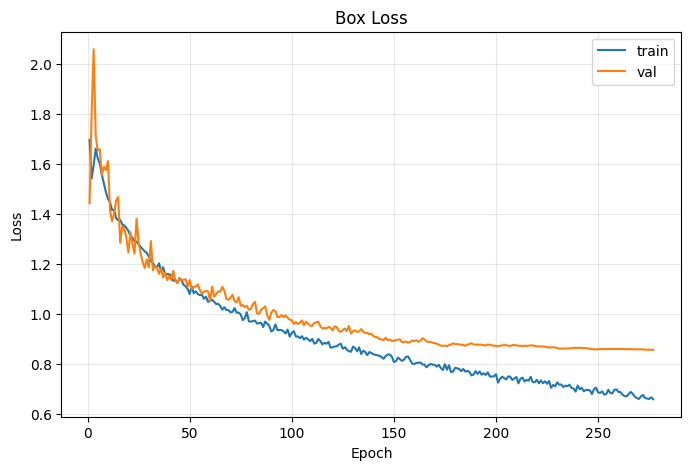

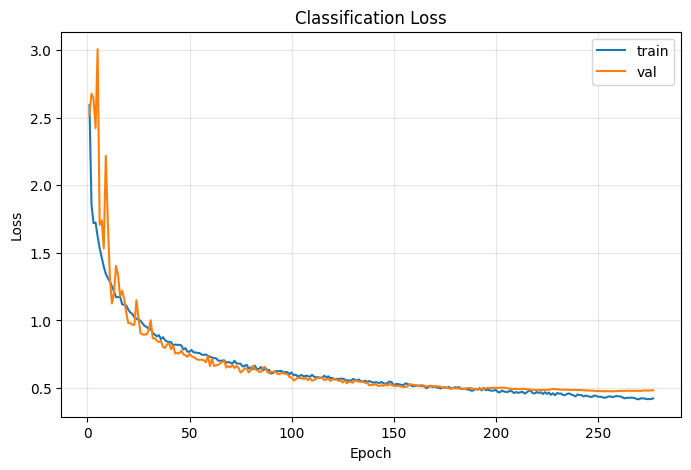

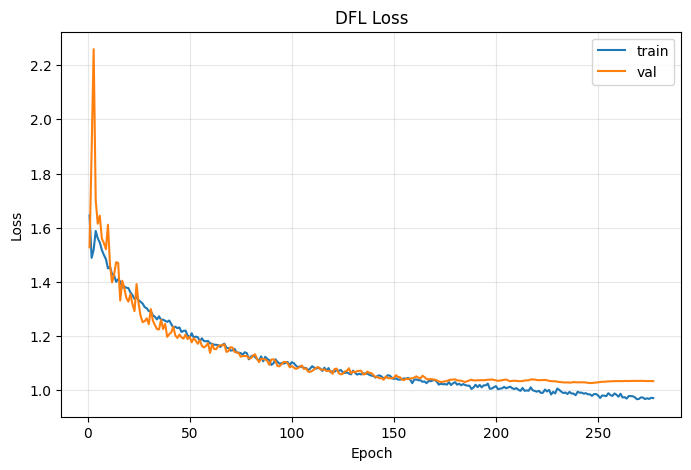

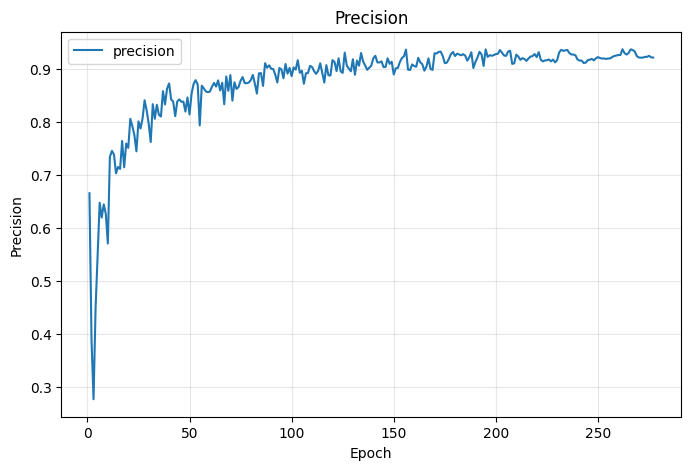

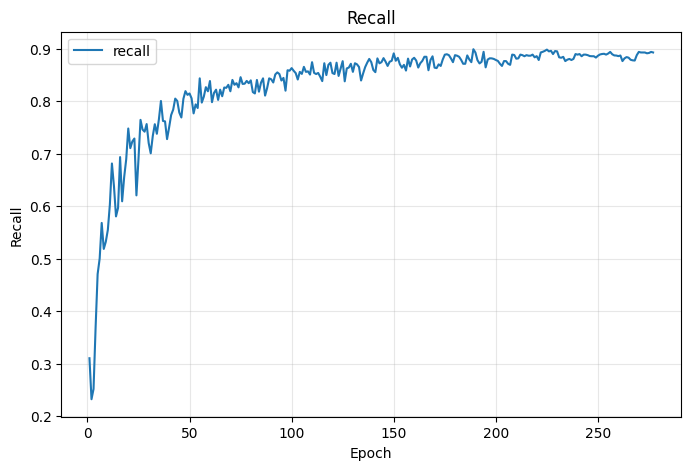

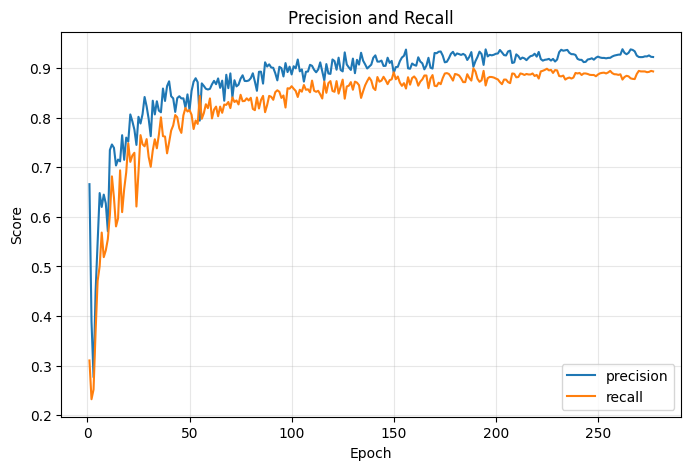

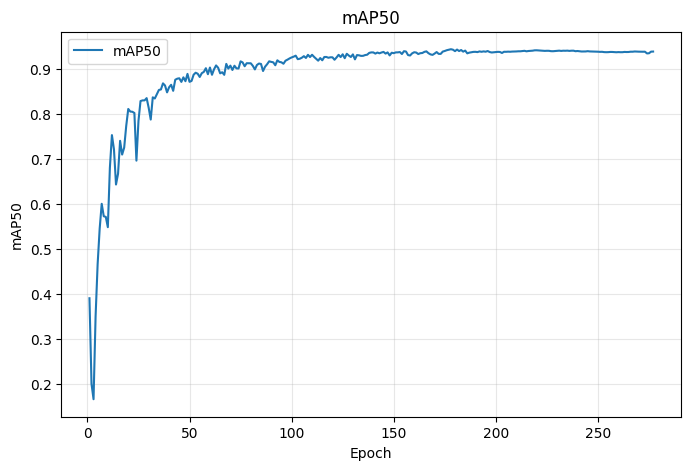

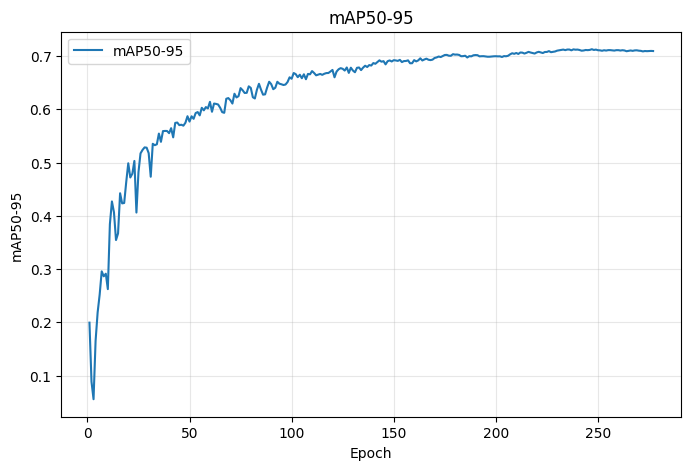

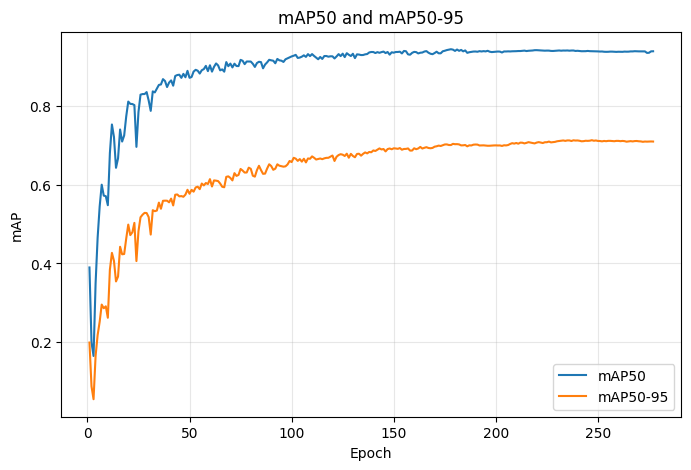


Saved plots:
  box_loss: /kaggle/working/plots/box_loss.png
  cls_loss: /kaggle/working/plots/cls_loss.png
  dfl_loss: /kaggle/working/plots/dfl_loss.png
  precision: /kaggle/working/plots/precision.png
  recall: /kaggle/working/plots/recall.png
  precision_recall_combined: /kaggle/working/plots/precision_recall.png
  mAP50: /kaggle/working/plots/map50.png
  mAP50_95: /kaggle/working/plots/map50_95.png
  mAP_combined: /kaggle/working/plots/map_combined.png

Final metrics summary:
  best_epoch: 247
  best_precision: 0.9196
  best_recall: 0.88592
  best_mAP50: 0.93845
  best_mAP50_95: 0.71271
  final_epoch_precision: 0.92216
  final_epoch_recall: 0.89311
  final_epoch_mAP50: 0.93831
  final_epoch_mAP50_95: 0.70931
  total_epochs_run: 278
  plot_paths: {'box_loss': '/kaggle/working/plots/box_loss.png', 'cls_loss': '/kaggle/working/plots/cls_loss.png', 'dfl_loss': '/kaggle/working/plots/dfl_loss.png', 'precision': '/kaggle/working/plots/precision.png', 'recall': '/kaggle/working/plots/rec

In [8]:
# Cell 6: Load Ultralytics' auto-generated results.csv and plot each metric
# as an individual figure, saved separately to disk.

import pandas as pd
import matplotlib.pyplot as plt

PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

RUN_DIR = os.path.join(RUNS_DIR, "yolov8n_pothole")
results_csv_path = os.path.join(RUN_DIR, "results.csv")

df = pd.read_csv(results_csv_path)
df.columns = [c.strip() for c in df.columns]

print(f"Logged epochs: {len(df)}")
print(df.columns.tolist())


def plot_and_save(x, series_dict, title, ylabel, filename):
    """Plot one or more series against a shared x-axis on its own figure,
    then save to disk and close the figure to free memory."""
    plt.figure(figsize=(8, 5))
    for label, y in series_dict.items():
        plt.plot(x, y, label=label)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    return path


plot_paths = {}

plot_paths["box_loss"] = plot_and_save(
    df["epoch"],
    {"train": df["train/box_loss"], "val": df["val/box_loss"]},
    "Box Loss", "Loss", "box_loss.png"
)

plot_paths["cls_loss"] = plot_and_save(
    df["epoch"],
    {"train": df["train/cls_loss"], "val": df["val/cls_loss"]},
    "Classification Loss", "Loss", "cls_loss.png"
)

plot_paths["dfl_loss"] = plot_and_save(
    df["epoch"],
    {"train": df["train/dfl_loss"], "val": df["val/dfl_loss"]},
    "DFL Loss", "Loss", "dfl_loss.png"
)

plot_paths["precision"] = plot_and_save(
    df["epoch"],
    {"precision": df["metrics/precision(B)"]},
    "Precision", "Precision", "precision.png"
)

plot_paths["recall"] = plot_and_save(
    df["epoch"],
    {"recall": df["metrics/recall(B)"]},
    "Recall", "Recall", "recall.png"
)

plot_paths["precision_recall_combined"] = plot_and_save(
    df["epoch"],
    {"precision": df["metrics/precision(B)"], "recall": df["metrics/recall(B)"]},
    "Precision and Recall", "Score", "precision_recall.png"
)

plot_paths["mAP50"] = plot_and_save(
    df["epoch"],
    {"mAP50": df["metrics/mAP50(B)"]},
    "mAP50", "mAP50", "map50.png"
)

plot_paths["mAP50_95"] = plot_and_save(
    df["epoch"],
    {"mAP50-95": df["metrics/mAP50-95(B)"]},
    "mAP50-95", "mAP50-95", "map50_95.png"
)

plot_paths["mAP_combined"] = plot_and_save(
    df["epoch"],
    {"mAP50": df["metrics/mAP50(B)"], "mAP50-95": df["metrics/mAP50-95(B)"]},
    "mAP50 and mAP50-95", "mAP", "map_combined.png"
)

print("\nSaved plots:")
for k, v in plot_paths.items():
    print(f"  {k}: {v}")

# Best epoch selected by highest mAP50-95, matching Ultralytics' own
# criterion for best.pt.
best_row = df.loc[df["metrics/mAP50-95(B)"].idxmax()]

final_metrics = {
    "best_epoch": int(best_row["epoch"]),
    "best_precision": float(best_row["metrics/precision(B)"]),
    "best_recall": float(best_row["metrics/recall(B)"]),
    "best_mAP50": float(best_row["metrics/mAP50(B)"]),
    "best_mAP50_95": float(best_row["metrics/mAP50-95(B)"]),
    "final_epoch_precision": float(df.iloc[-1]["metrics/precision(B)"]),
    "final_epoch_recall": float(df.iloc[-1]["metrics/recall(B)"]),
    "final_epoch_mAP50": float(df.iloc[-1]["metrics/mAP50(B)"]),
    "final_epoch_mAP50_95": float(df.iloc[-1]["metrics/mAP50-95(B)"]),
    "total_epochs_run": int(df["epoch"].max()) + 1,
    "plot_paths": plot_paths,
}

print("\nFinal metrics summary:")
for k, v in final_metrics.items():
    print(f"  {k}: {v}")

save_results({"training_metrics": final_metrics})

# Print full contents of results.json so all accumulated results across
# every cell so far are visible in one place.
print("\nFull results.json contents so far:")
print(json.dumps(load_results(), indent=2))

In [9]:
# Cell 7: Export the best trained checkpoint to both ONNX and NCNN formats
# for a side-by-side edge-deployment comparison.

from ultralytics import YOLO

best_checkpoint_path = os.path.join(RUNS_DIR, "yolov8n_pothole", "weights", "best.pt")
print(f"Loading best checkpoint from: {best_checkpoint_path}")

trained_model = YOLO(best_checkpoint_path)

# ONNX export, with dynamic quantization applied in a later cell via
# onnxruntime's quantize_dynamic. The export itself here is full precision.
onnx_export_path = trained_model.export(format="onnx", imgsz=640, dynamic=False, simplify=True)
print(f"ONNX export path: {onnx_export_path}")

# NCNN export. NCNN's own toolchain applies its own optimized ARM-targeted
# graph representation (.param + .bin files), distinct from ONNX's graph
# format. Ultralytics handles the PNNX intermediate conversion internally.
ncnn_export_path = trained_model.export(format="ncnn", imgsz=640)
print(f"NCNN export path: {ncnn_export_path}")

# Record file sizes for both exports as the first comparison axis.
def get_dir_or_file_size_mb(path):
    if os.path.isdir(path):
        total = sum(
            os.path.getsize(os.path.join(dirpath, f))
            for dirpath, _, filenames in os.walk(path)
            for f in filenames
        )
        return total / (1024 ** 2)
    else:
        return os.path.getsize(path) / (1024 ** 2)

onnx_size_mb = get_dir_or_file_size_mb(onnx_export_path)
ncnn_size_mb = get_dir_or_file_size_mb(ncnn_export_path)

print(f"\nONNX export size: {onnx_size_mb:.2f} MB")
print(f"NCNN export size: {ncnn_size_mb:.2f} MB")

save_results({
    "export_paths": {
        "onnx": str(onnx_export_path),
        "ncnn": str(ncnn_export_path),
    },
    "export_sizes_mb": {
        "onnx": round(onnx_size_mb, 2),
        "ncnn": round(ncnn_size_mb, 2),
    },
})

Loading best checkpoint from: /kaggle/working/runs/yolov8n_pothole/weights/best.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/kaggle/working/runs/yolov8n_pothole/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 291ms
Prepared 2 packages in 287ms
Installed 2 packages in 14ms
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.

pnnxparam = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model.pnnx.param
pnnxbin = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model.pnnx.bin
pnnxpy = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model_pnnx.py
pnnxonnx = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model.pnnx.onnx
ncnnparam = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model.ncnn.param
ncnnbin = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model.ncnn.bin
ncnnpy = /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model/model_ncnn.py
fp16 = 0
optlevel = 2
device = cpu
inputshape = [1,3,640,640]f32
inputshape2 = 
input = 
input2 = 
customop = 
moduleop = 
get inputshape from traced inputs
inputshape = [1,3,640,640]f32
############# pass_level0
inline module = torch.nn.modules.linear.Identity
inline module = ultralytics.nn.modules.block.Bottleneck
inline module = ultralytics.nn.modules.block.C2f
inline module = ultralyti

NCNN: export success ✅ 5.4s, saved as '/kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model' (11.6 MB)

Export complete (5.7s)
Results saved to /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model
Predict:         yolo predict task=detect model=/kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model imgsz=640 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app
NCNN export path: /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model

ONNX export size: 11.70 MB
NCNN export size: 11.63 MB


In [10]:
# Cell 8: Benchmark inference latency and throughput across PyTorch,
# ONNX, and NCNN formats, all forced to CPU-only execution.

from ultralytics import YOLO
import numpy as np

NUM_WARMUP = 5
NUM_RUNS = 50

test_images_dir = os.path.join(DATASET_ROOT, "test", "images")
test_image_files = sorted(os.listdir(test_images_dir))[:NUM_RUNS]
test_image_paths = [os.path.join(test_images_dir, f) for f in test_image_files]

print(f"Benchmarking on {len(test_image_paths)} test images, CPU-only, "
      f"{NUM_WARMUP} warmup runs excluded from timing.")


def benchmark_model(model_path, format_label, imgsz=640):
    """Run repeated single-image inference on CPU and record per-image
    latency. Warmup runs are discarded since the first few inferences
    include one-time initialization overhead not representative of
    steady-state performance."""
    model = YOLO(model_path, task="detect")

    # Warmup
    for path in test_image_paths[:NUM_WARMUP]:
        _ = model.predict(path, device="cpu", imgsz=imgsz, verbose=False)

    latencies = []
    for path in test_image_paths:
        start = time.time()
        _ = model.predict(path, device="cpu", imgsz=imgsz, verbose=False)
        latencies.append((time.time() - start) * 1000)  # milliseconds

    return {
        "format": format_label,
        "mean_latency_ms": float(np.mean(latencies)),
        "std_latency_ms": float(np.std(latencies)),
        "min_latency_ms": float(np.min(latencies)),
        "max_latency_ms": float(np.max(latencies)),
        "throughput_fps": float(1000 / np.mean(latencies)),
    }


benchmark_results = []

pytorch_bench = benchmark_model(best_checkpoint_path, "PyTorch (.pt)")
benchmark_results.append(pytorch_bench)
print(f"\nPyTorch CPU: {pytorch_bench}")

onnx_bench = benchmark_model(onnx_export_path, "ONNX")
benchmark_results.append(onnx_bench)
print(f"\nONNX CPU: {onnx_bench}")

ncnn_bench = benchmark_model(ncnn_export_path, "NCNN")
benchmark_results.append(ncnn_bench)
print(f"\nNCNN CPU: {ncnn_bench}")

save_results({"cpu_benchmark": benchmark_results})

Benchmarking on 50 test images, CPU-only, 5 warmup runs excluded from timing.

PyTorch CPU: {'format': 'PyTorch (.pt)', 'mean_latency_ms': 121.66613101959229, 'std_latency_ms': 4.340571139592316, 'min_latency_ms': 111.2203598022461, 'max_latency_ms': 131.64258003234863, 'throughput_fps': 8.219214267929395}
Loading /kaggle/working/runs/yolov8n_pothole/weights/best.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.27.0 with CPUExecutionProvider

ONNX CPU: {'format': 'ONNX', 'mean_latency_ms': 112.83555030822754, 'std_latency_ms': 3.1841691578478546, 'min_latency_ms': 107.06615447998047, 'max_latency_ms': 120.92781066894531, 'throughput_fps': 8.862455115150741}
Loading /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model for NCNN inference...

NCNN CPU: {'format': 'NCNN', 'mean_latency_ms': 95.02709865570068, 'std_latency_ms': 11.243425722519984, 'min_latency_ms': 83.27007293701172, 'max_latency_ms': 127.42972373962402, 'throughput_fps': 10.523314024593867}


In [11]:
# Cell 9: Validate accuracy (mAP) for each exported format on the test
# split, then assemble the final size/speed/accuracy comparison table.

from ultralytics import YOLO

def validate_model(model_path, format_label):
    model = YOLO(model_path, task="detect")
    metrics = model.val(data=corrected_yaml_path, split="test", device="cpu", verbose=False)
    return {
        "format": format_label,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
    }


accuracy_results = []

pytorch_acc = validate_model(best_checkpoint_path, "PyTorch (.pt)")
accuracy_results.append(pytorch_acc)
print(f"PyTorch accuracy: {pytorch_acc}")

onnx_acc = validate_model(onnx_export_path, "ONNX")
accuracy_results.append(onnx_acc)
print(f"ONNX accuracy: {onnx_acc}")

ncnn_acc = validate_model(ncnn_export_path, "NCNN")
accuracy_results.append(ncnn_acc)
print(f"NCNN accuracy: {ncnn_acc}")

# Merge speed and accuracy results into one final comparison table, keyed
# by format, combining data already gathered in results.json from Cell 7
# (sizes) and Cell 8 (latency/throughput).
all_results = load_results()
size_data = all_results["export_sizes_mb"]
speed_data = {r["format"]: r for r in all_results["cpu_benchmark"]}

comparison_table = []
format_key_map = {"PyTorch (.pt)": "pytorch", "ONNX": "onnx", "NCNN": "ncnn"}

for acc_row in accuracy_results:
    fmt = acc_row["format"]
    size_key = format_key_map.get(fmt, fmt.lower())
    row = {
        "format": fmt,
        "size_mb": size_data.get(size_key, None),
        "mean_latency_ms": speed_data.get(fmt, {}).get("mean_latency_ms"),
        "throughput_fps": speed_data.get(fmt, {}).get("throughput_fps"),
        "precision": acc_row["precision"],
        "recall": acc_row["recall"],
        "mAP50": acc_row["mAP50"],
        "mAP50_95": acc_row["mAP50_95"],
    }
    comparison_table.append(row)

print("\nFinal comparison table:")
for row in comparison_table:
    print(row)

save_results({"final_comparison_table": comparison_table})

print("\nFull results.json contents:")
print(json.dumps(load_results(), indent=2))

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.9±1.2 ms, read: 15.4±19.7 MB/s, size: 47.2 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/test/labels... 198 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 210.7it/s 0.9s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1s/it 27.5s2.2s
                   all        198        433      0.941      0.886      0.936      0.713
Speed: 2.9ms preprocess, 124.8m

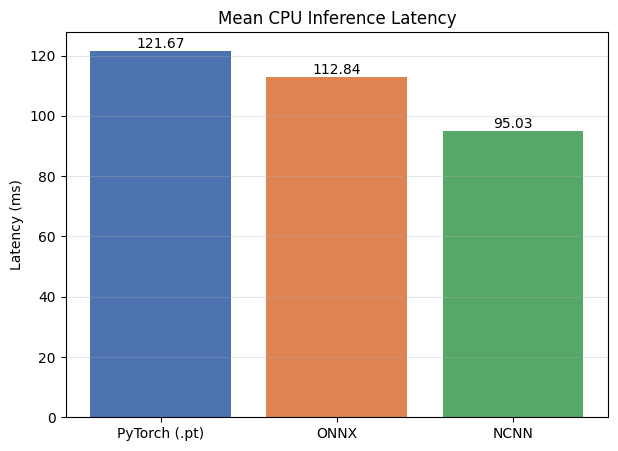

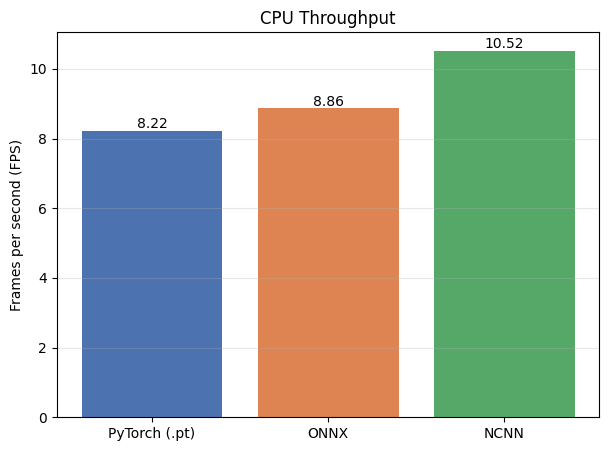

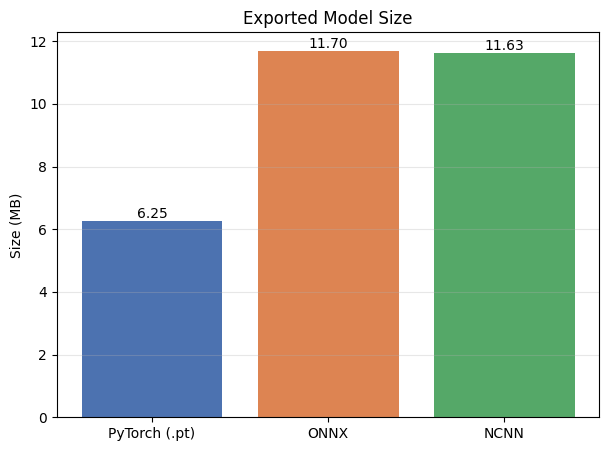

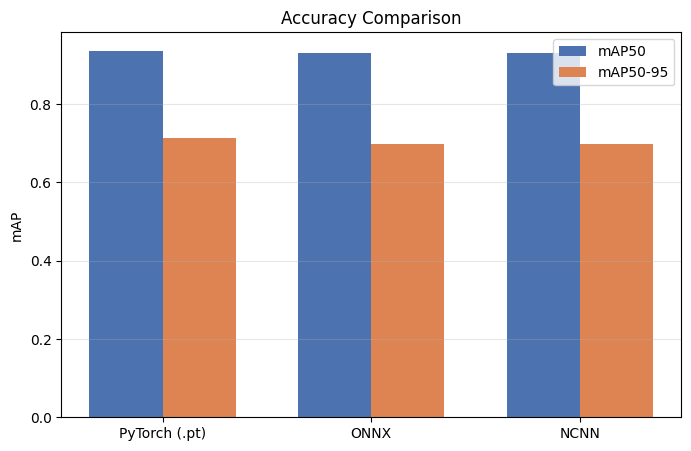

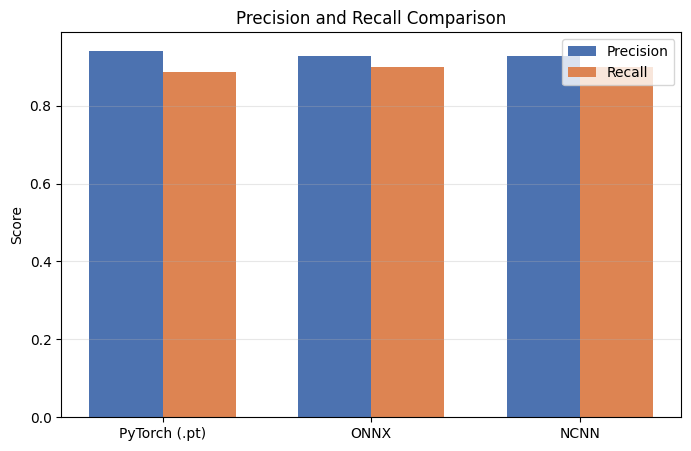

Saved comparison plots:
  latency: /kaggle/working/plots/comparison_latency.png
  fps: /kaggle/working/plots/comparison_fps.png
  size: /kaggle/working/plots/comparison_size.png
  accuracy_map: /kaggle/working/plots/comparison_map.png
  precision_recall: /kaggle/working/plots/comparison_precision_recall.png

Full results.json contents:
{
  "environment": {
    "torch_version": "2.10.0+cu128",
    "cuda_available": true,
    "num_gpus": 2,
    "gpu_names": [
      "Tesla T4",
      "Tesla T4"
    ],
    "python_version": "3.12.13"
  },
  "base_model": "yolov8n.pt",
  "base_checkpoint_size_mb": 6.25,
  "dataset_root": "/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized",
  "existing_yaml_found": [
    "/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/data.yaml"
  ],
  "data_yaml_path": "/kaggle/working/data.yaml",
  "num_classes": 1,
  "class_names": [
    "pothole"
  ],
  "training_epochs_requested": 100,
  "training_elapsed_

In [12]:
# Cell 10: Visualize CPU-only performance comparison across formats,
# covering latency, FPS, size, and accuracy metrics side by side.

import matplotlib.pyplot as plt
import numpy as np

results_all = load_results()
comparison_table = results_all["final_comparison_table"]

# Backfill PyTorch's size, which was not recorded during export (Cell 7
# only exported ONNX/NCNN); the original checkpoint size was captured
# earlier in results.json under base_checkpoint_size_mb.
for row in comparison_table:
    if row["format"] == "PyTorch (.pt)" and row["size_mb"] is None:
        row["size_mb"] = results_all["base_checkpoint_size_mb"]

formats = [row["format"] for row in comparison_table]
latencies = [row["mean_latency_ms"] for row in comparison_table]
fps_values = [row["throughput_fps"] for row in comparison_table]
sizes = [row["size_mb"] for row in comparison_table]
map50_values = [row["mAP50"] for row in comparison_table]
map50_95_values = [row["mAP50_95"] for row in comparison_table]
precision_values = [row["precision"] for row in comparison_table]
recall_values = [row["recall"] for row in comparison_table]

colors = ["#4C72B0", "#DD8452", "#55A868"]


def bar_plot(labels, values, title, ylabel, filename, value_fmt="{:.2f}"):
    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=colors[:len(labels)])
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                  value_fmt.format(val), ha="center", va="bottom", fontsize=10)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(True, axis="y", alpha=0.3)
    path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    return path


comparison_plot_paths = {}

# Latency: lower is better, this is the direct CPU inference cost per image.
comparison_plot_paths["latency"] = bar_plot(
    formats, latencies, "Mean CPU Inference Latency", "Latency (ms)",
    "comparison_latency.png"
)

# FPS: derived directly from latency (1000 / mean_latency_ms), shown
# separately since it is the more intuitive figure for real-time deployment
# feasibility on the target device.
comparison_plot_paths["fps"] = bar_plot(
    formats, fps_values, "CPU Throughput", "Frames per second (FPS)",
    "comparison_fps.png"
)

# Size: total exported file/directory size on disk.
comparison_plot_paths["size"] = bar_plot(
    formats, sizes, "Exported Model Size", "Size (MB)",
    "comparison_size.png"
)

# Accuracy: mAP50 and mAP50-95 shown together since both matter for
# understanding detection quality at different IoU strictness levels.
plt.figure(figsize=(8, 5))
x = np.arange(len(formats))
width = 0.35
plt.bar(x - width / 2, map50_values, width, label="mAP50", color=colors[0])
plt.bar(x + width / 2, map50_95_values, width, label="mAP50-95", color=colors[1])
plt.xticks(x, formats)
plt.title("Accuracy Comparison")
plt.ylabel("mAP")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
map_path = os.path.join(PLOTS_DIR, "comparison_map.png")
plt.savefig(map_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
comparison_plot_paths["accuracy_map"] = map_path

# Precision and recall shown together for the same reason.
plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, precision_values, width, label="Precision", color=colors[0])
plt.bar(x + width / 2, recall_values, width, label="Recall", color=colors[1])
plt.xticks(x, formats)
plt.title("Precision and Recall Comparison")
plt.ylabel("Score")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
pr_path = os.path.join(PLOTS_DIR, "comparison_precision_recall.png")
plt.savefig(pr_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
comparison_plot_paths["precision_recall"] = pr_path

print("Saved comparison plots:")
for k, v in comparison_plot_paths.items():
    print(f"  {k}: {v}")

save_results({
    "final_comparison_table": comparison_table,
    "comparison_plot_paths": comparison_plot_paths,
})

print("\nFull results.json contents:")

print(json.dumps(load_results(), indent=2))

37_jpg.rf.fcb3d7373721a8d2bbfa8e3e439948ad.jpg: 4 pothole(s) detected
potholes429_png.rf.3302b3510d3a7cf491bee1171acb8e7c.jpg: 1 pothole(s) detected
potholes52_png.rf.bf6cd93e929162d4486815d99ddf1e81.jpg: 1 pothole(s) detected
potholes403_png.rf.9ef94a96f348aea516b954c8e111d5d3.jpg: 3 pothole(s) detected
potholes260_png.rf.2b867525637a618083f4e73ac7907b92.jpg: 1 pothole(s) detected
potholes266_png.rf.cf47c37a615c75796cfb1d1f772e5e32.jpg: 5 pothole(s) detected
41_jpg.rf.8f95f446c589335f9ae1b642af1c4e85.jpg: 8 pothole(s) detected
potholes460_png.rf.6979a58f1e799fe0e20ef5a8c5c728cd.jpg: 2 pothole(s) detected


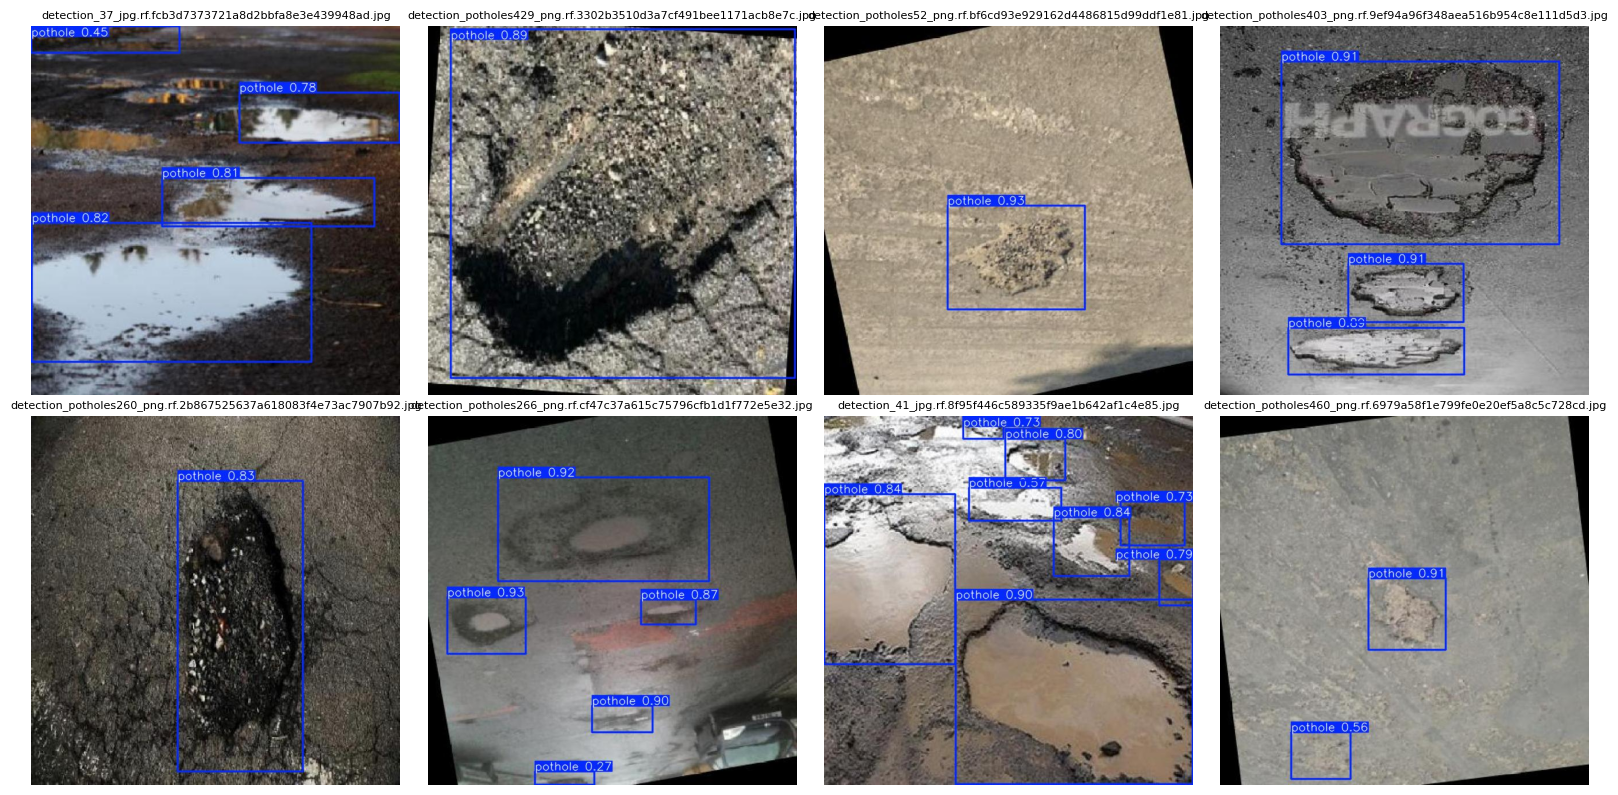


Saved detection grid to: /kaggle/working/plots/sample_detections_grid.png

Full results.json contents:
{
  "environment": {
    "torch_version": "2.10.0+cu128",
    "cuda_available": true,
    "num_gpus": 2,
    "gpu_names": [
      "Tesla T4",
      "Tesla T4"
    ],
    "python_version": "3.12.13"
  },
  "base_model": "yolov8n.pt",
  "base_checkpoint_size_mb": 6.25,
  "dataset_root": "/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized",
  "existing_yaml_found": [
    "/kaggle/input/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized/data.yaml"
  ],
  "data_yaml_path": "/kaggle/working/data.yaml",
  "num_classes": 1,
  "class_names": [
    "pothole"
  ],
  "training_epochs_requested": 100,
  "training_elapsed_minutes_this_session": 168.09,
  "resumed_from_checkpoint": false,
  "run_dir": "/kaggle/working/runs/detect/yolov8n_pothole",
  "training_metrics": {
    "best_epoch": 247,
    "best_precision": 0.9196,
    "best_recall": 0.88592,
  

In [14]:
# Cell 11: Run detection on a sample of test images using the trained
# model, visualize bounding boxes, and save annotated outputs to disk.

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np

SAMPLE_DETECTION_DIR = os.path.join(BASE_DIR, "sample_detections")
os.makedirs(SAMPLE_DETECTION_DIR, exist_ok=True)

NUM_SAMPLES = 8

test_images_dir = os.path.join(DATASET_ROOT, "test", "images")
all_test_images = sorted(os.listdir(test_images_dir))

rng = np.random.default_rng(seed=42)
sample_files = rng.choice(all_test_images, size=NUM_SAMPLES, replace=False)
sample_paths = [os.path.join(test_images_dir, f) for f in sample_files]

detection_model = YOLO(best_checkpoint_path, task="detect")

saved_detection_paths = []
detection_summary = []

for path in sample_paths:
    result = detection_model.predict(path, device="cpu", conf=0.25, verbose=False)[0]

    annotated = result.plot()  # returns a BGR numpy array with boxes drawn
    save_name = f"detection_{os.path.splitext(os.path.basename(path))[0]}.jpg"
    save_path = os.path.join(SAMPLE_DETECTION_DIR, save_name)

    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    Image.fromarray(annotated_rgb).save(save_path)

    saved_detection_paths.append(save_path)
    detection_summary.append({
        "image": os.path.basename(path),
        "num_detections": len(result.boxes),
        "confidences": [float(c) for c in result.boxes.conf] if len(result.boxes) > 0 else [],
        "saved_path": save_path,
    })

    print(f"{os.path.basename(path)}: {len(result.boxes)} pothole(s) detected")

cols = 4
rows = int(np.ceil(NUM_SAMPLES / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for ax, path in zip(axes, saved_detection_paths):
    img = mpimg.imread(path)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(os.path.basename(path), fontsize=8)

for ax in axes[len(saved_detection_paths):]:
    ax.axis("off")

plt.tight_layout()
grid_path = os.path.join(PLOTS_DIR, "sample_detections_grid.png")
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved detection grid to: {grid_path}")

save_results({
    "sample_detections": {
        "individual_images": saved_detection_paths,
        "grid_image": grid_path,
        "summary": detection_summary,
    }
})

print("\nFull results.json contents:")
print(json.dumps(load_results(), indent=2))

In [15]:
# Cell 12: Package all generated artifacts (checkpoints, exports, plots,
# results.json, sample detections) into a single zip file for download.

import shutil

ZIP_NAME = "pothole_detection_project_outputs"
zip_output_path = os.path.join(BASE_DIR, ZIP_NAME)

# Directories/files to include. Raw dataset images are deliberately
# excluded since they belong to the read-only input mount, not something
# this project generated, and re-zipping them would bloat the archive
# well beyond what is actually needed.
items_to_include = [
    os.path.join(RUNS_DIR, "yolov8n_pothole", "weights", "best.pt"),
    os.path.join(RUNS_DIR, "yolov8n_pothole", "weights", "last.pt"),
    os.path.join(RUNS_DIR, "yolov8n_pothole", "weights", "best.onnx"),
    os.path.join(RUNS_DIR, "yolov8n_pothole", "weights", "best_ncnn_model"),
    os.path.join(RUNS_DIR, "yolov8n_pothole", "results.csv"),
    PLOTS_DIR,
    SAMPLE_DETECTION_DIR,
    RESULTS_FILE,
    os.path.join(BASE_DIR, "data.yaml"),
]

# Stage everything into one temp folder first, preserving a clear structure,
# since shutil.make_archive zips a single directory rather than an
# arbitrary list of scattered paths.
staging_dir = os.path.join(BASE_DIR, "staging_for_zip")
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir)

for item in items_to_include:
    if not os.path.exists(item):
        print(f"Skipping missing path: {item}")
        continue

    dest_name = os.path.basename(item.rstrip("/"))
    dest_path = os.path.join(staging_dir, dest_name)

    if os.path.isdir(item):
        shutil.copytree(item, dest_path)
    else:
        shutil.copy2(item, dest_path)

    print(f"Staged: {item} -> {dest_path}")

# Create the zip archive from the staged directory.
shutil.make_archive(zip_output_path, "zip", staging_dir)

final_zip_path = zip_output_path + ".zip"
zip_size_mb = os.path.getsize(final_zip_path) / (1024 ** 2)

print(f"\nZip created: {final_zip_path}")
print(f"Zip size: {zip_size_mb:.2f} MB")

# Clean up the staging directory now that the archive exists, to avoid
# duplicate storage counting against the output quota.
shutil.rmtree(staging_dir)

save_results({"final_zip_path": final_zip_path, "final_zip_size_mb": round(zip_size_mb, 2)})

Staged: /kaggle/working/runs/yolov8n_pothole/weights/best.pt -> /kaggle/working/staging_for_zip/best.pt
Staged: /kaggle/working/runs/yolov8n_pothole/weights/last.pt -> /kaggle/working/staging_for_zip/last.pt
Staged: /kaggle/working/runs/yolov8n_pothole/weights/best.onnx -> /kaggle/working/staging_for_zip/best.onnx
Staged: /kaggle/working/runs/yolov8n_pothole/weights/best_ncnn_model -> /kaggle/working/staging_for_zip/best_ncnn_model
Staged: /kaggle/working/runs/yolov8n_pothole/results.csv -> /kaggle/working/staging_for_zip/results.csv
Staged: /kaggle/working/plots -> /kaggle/working/staging_for_zip/plots
Staged: /kaggle/working/sample_detections -> /kaggle/working/staging_for_zip/sample_detections
Staged: /kaggle/working/results/results.json -> /kaggle/working/staging_for_zip/results.json
Staged: /kaggle/working/data.yaml -> /kaggle/working/staging_for_zip/data.yaml

Zip created: /kaggle/working/pothole_detection_project_outputs.zip
Zip size: 35.44 MB
